In [1]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

/Users/apple/Desktop/prep/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [3]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [4]:
class State(TypedDict):
    topic: str
    plan: Plan
    #reducere: result from workers get concatinated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [5]:
llm = ChatOpenAI(model="gpt-4.1-mini")

In [6]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [7]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [8]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [9]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [10]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

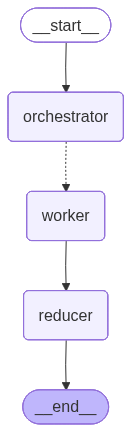

In [11]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [12]:

out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

In [13]:
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self Attention: A Key Concept in Modern AI', tasks=[Task(id=1, title='Introduction to Self Attention', brief='Explain the concept of self attention and its significance in machine learning and natural language processing.'), Task(id=2, title='How Self Attention Works', brief='Describe the mechanism of self attention, including queries, keys, and values, and how they interact.'), Task(id=3, title='Self Attention in Transformer Models', brief='Discuss the role of self attention in transformer architectures and why it is critical for their success.'), Task(id=4, title='Benefits of Self Attention', brief='Highlight the advantages of self attention compared to previous techniques like RNNs and CNNs.'), Task(id=5, title='Real-world Applications', brief='Provide examples of applications where self attention enhances performance, such as language translation and text summarization.'), Task(id=6, title='Challeng

In [15]:
print(out["final"])

# Understanding Self Attention: A Key Concept in Modern AI

## Introduction to Self Attention

Self attention is a powerful mechanism in machine learning, particularly within the field of natural language processing (NLP). At its core, self attention allows a model to weigh the importance of different words or elements within a single sequence when generating an output. Instead of processing input data in a fixed or sequential manner, self attention enables the model to dynamically focus on relevant parts of the sequence, regardless of their position.

This capability is crucial for understanding context, as the meaning of a word often depends on other words scattered throughout a sentence or paragraph. For example, in the sentence *“The cat, which was hungry, ate the food,”* self attention helps the model link the word "cat" to descriptors like "hungry" even though they are separated by several words.

The introduction of self attention has transformed how models like Transformers han